# Example notebook for NV center in diamond Lindblad master equation simulations.

## Importing Packages

In [14]:
# !pip install qutip
# Generally useful packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure, show, grid, tight_layout
plt.rcParams.update({'font.sans-serif':'DejaVu Sans'})

# Make the Jupyter Notebook fill 90 percent of the screen (nerd_mode)
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 90% !important; }</style>"))

# import qutip for quantum calculations
from qutip import *

## Defining the Hamiltonian. Using a 7-level description.

In [15]:
################################ Global constants (units and defaults)  ###########################
# Axial zero-field splitting
D_MHz = 2870.0
# D in rad/s (for reference)
D_rad_s = 2 * np.pi * 2.87e9
# Gyromagnetic ratio of NV (rad/s/G)
gamma_nv = 2 * np.pi * 2.8e6
# External magnetic field (Gauss)
B = 0.0

# Default transverse strain splitting (rad/s) -- user can override in sweeps
# Suggested range: 0 to 50 MHz -> convert to rad/s via 2*pi
E_rad_s = 2 * np.pi * 10.0e6 * 2
# Angle of strain axis in xy plane (radians)
strain_angle = np.pi / 4


# - D_MHz is used in D_of_T by default. Use D_rad_s or gamma_nv if you add Zeeman in rad/s when accounting for magnetic field.
# - E_rad_s is stored in rad/s; NV_ODMR converts as needed to MHz to match other terms.
# - the global constants will be called in autonomous model

In [16]:
# Defining basis functions for the 7 level basis
# gs - ground electronic state, 0- m=0, m1- m=-1, p1- m=+1
# es - excited electronic state, 0- m=0, m1- m=-1, p1- m=+1
# shelf - singlet shelving state

gs_0 = basis(7,0)
gs_m1 = basis(7,1)
gs_p1 = basis(7,2)
es_0 = basis(7,3)
es_m1 = basis(7,4)
es_p1 = basis(7,5)
shelf_state = basis(7,6)


# No applied magnetic field - all the spin states are degenerate
# Units: [us/MHz]
# NV center optical transition energy: 637.1 nm ~ 1.945 eV ~ 470.8 THz = 4.708 x 10^(8) MHz
# placed the shelving state halfway between the ground and excited states, which is, not true
# factor of 2*pi to make this into an angular frequency
H_0 = 2 * np.pi * (4.708E8*es_p1*es_p1.dag()
                    + 4.708E8*es_0*es_0.dag()
                    + 4.708E8*es_m1*es_m1.dag()
                    + 0.5*4.708E8*shelf_state*shelf_state.dag())

## Define an initial density matrix

In [17]:
# assuming initial density is thermal (1/3 in each of the three ground states)

rho_0 = (1/3)*(gs_0*gs_0.dag() + gs_m1*gs_m1.dag() + gs_p1*gs_p1.dag())


## Definte transition rates

In [18]:
# Define transition rates

rate_laser = 1/0.01 #rate of excitation  changed to 0.01 from 0.1
rate_eg = 1/0.012 #rate of relaxation from the ES to GS (give off a photon)
rate_isc = 1/0.045 #rate of relaxing from the ES to the shelve state
rate_sg = 1/0.300 #rate of relaxing from the shelve state to the ground state
rate_T1 = 1E-99 # rate of T1 process happening in the GS/ES prob= e^-t/T1. Usually T1 is in ms, we just make T1 rate very small here

# where are these numbers from - generally, Lucio Robledo's work - https://iopscience.iop.org/article/10.1088/1367-2630/13/2/025013/pdf

## Define collapse operators

In [19]:
dim = 7

# Laser Pumping (rename variables to cop_ab where a=source index, b=dest index)
cop_03 = np.sqrt(rate_laser)*es_0*gs_0.dag() # 0 -> 3 (gs_0 -> es_0)
cop_14 = np.sqrt(rate_laser)*es_m1*gs_m1.dag() # 1 -> 4 (gs_m1 -> es_m1)
cop_25 = np.sqrt(rate_laser)*es_p1*gs_p1.dag() # 2 -> 5 (gs_p1 -> es_p1)

# T1 processes (ground-state flips) - names corrected to match operator semantics
cop_01 = np.sqrt(rate_T1)*gs_m1*gs_0.dag()  # 0 -> 1
cop_12 = np.sqrt(rate_T1)*gs_p1*gs_m1.dag() # 1 -> 2
cop_20 = np.sqrt(rate_T1)*gs_0*gs_p1.dag()  # 2 -> 0

# provide dag versions if code expects both directions
cop_10 = cop_01.dag()
cop_21 = cop_12.dag()
cop_02 = cop_20.dag()

# Spontaneous emission (excited -> ground) - corrected naming
cop_30 = np.sqrt(rate_eg)*gs_0*es_0.dag() # 3 -> 0
cop_41 = np.sqrt(rate_eg)*gs_m1*es_m1.dag() # 4 -> 1
cop_52 = np.sqrt(rate_eg)*gs_p1*es_p1.dag() # 5 -> 2

# ISC (excited -> shelf) - corrected naming and keep expressions
cop_36 = np.sqrt(rate_isc/10)*shelf_state*es_0.dag() # 3 -> 6 (es_0 -> shelf)
cop_46 = np.sqrt(rate_isc)*shelf_state*es_m1.dag()     # 4 -> 6
cop_56 = np.sqrt(rate_isc)*shelf_state*es_p1.dag()     # 5 -> 6

cop_60 = np.sqrt(rate_sg)*gs_0*shelf_state.dag() # 6 -> 0
cop_61 = np.sqrt(rate_sg)*gs_m1*shelf_state.dag()
cop_62 = np.sqrt(rate_sg)*gs_p1*shelf_state.dag()

cops = [cop_03, cop_14, cop_25, cop_01, cop_12, cop_20, cop_10, cop_21, cop_02, cop_30, cop_41, cop_52, cop_36, cop_46, cop_56, cop_60, cop_61, cop_62]


## defining an 7x7 Sz operator

In [20]:
#row1=[1,0,0,0,0,0,0] #row 1-3 are the GS states
#row2=[0,0,0,0,0,0,0]
#row3=[0,0,-1,0,0,0,0]
#row4=[0,0,0,0,0,0,0] #row 4-6 are the ES states
#row5=[0,0,0,0,0,0,0]
#row6=[0,0,0,0,0,0,0]
#row7=[0,0,0,0,0,0,0] # row 7 is the shelving state

#Sz = Qobj(np.array([row1, row2, row3, row4, row5, row6, row7]))
Sz = gs_0*gs_0.dag() - gs_p1*gs_p1.dag() + es_0*es_0.dag() - es_p1*es_p1.dag()

print(Sz.full())

[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]]


## defining functions for state evolution under optical pumping

In [21]:
# evolution of state while optically pumping (outputs the expectation value of the expect_op)
def evolve_optical_pumping(rho_0, H, t_end, num_pts, c_op_list, expect_op):
  tlist = np.linspace(0, t_end, num_pts)
  output = mesolve(H, rho_0, tlist, c_op_list, [expect_op])

  return output

# evolution of state while optically pumping (outputs the density matrices / state list)
def evolve_optical_pumping_ds(rho_0, H, t_end, num_pts, c_op_list):
  tlist = np.linspace(0, t_end, num_pts)
  output = mesolve(H, rho_0, tlist, c_op_list)

  return output

## Example: optically pump for 3 us, 1000 points, return density matrix

In [22]:
output = evolve_optical_pumping_ds(rho_0, H_0, 3, 1000, cops)
rho_polarized_0 = output.states[-1]
print(rho_polarized_0)
# outputting the last of the 1000 points in the numerical evolution
# you can see that quite a lot of the population is in the ground and excited state spin 0 states,
# and also quite a lot in the shelf under this constant laser excitation

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.29164723 0.         0.         0.         0.         0.
  0.        ]
 [0.         0.03598981 0.         0.         0.         0.
  0.        ]
 [0.         0.         0.03598981 0.         0.         0.
  0.        ]
 [0.         0.         0.         0.34088542 0.         0.
  0.        ]
 [0.         0.         0.         0.         0.03409579 0.
  0.        ]
 [0.         0.         0.         0.         0.         0.03409579
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.22729616]]


      # Dynamic T1/T2 rates (units: 1/us)
      T1_us = T1_of_T(T)
      rate_T1_dyn = 1.0 / T1_us
      T2_us = T2_of_T(T)
      rate_deph = 1.0 / T2_us

      # Reconstruct T1-related collapse operators with temperature-dependent rates
      cop_01_dyn = np.sqrt(rate_T1_dyn) * gs_m1 * gs_0.dag()
      cop_12_dyn = np.sqrt(rate_T1_dyn) * gs_p1 * gs_m1.dag()
      cop_20_dyn = np.sqrt(rate_T1_dyn) * gs_0 * gs_p1.dag()
      cop_10_dyn = cop_01_dyn.dag()
      cop_21_dyn = cop_12_dyn.dag()
      cop_02_dyn = cop_20_dyn.dag()

      # Pure dephasing on ground states (phenomenological)
      cop_phi0 = np.sqrt(rate_deph) * gs_0 * gs_0.dag()
      cop_phim1 = np.sqrt(rate_deph) * gs_m1 * gs_m1.dag()
      cop_phip1 = np.sqrt(rate_deph) * gs_p1 * gs_p1.dag()

      # Build dynamic collapse list: use radiative/ISC/shelve operators already defined globally,
      # but replace the static T1 operators with the dynamic versions and add dephasing.
      dynamic_cops = [cop_03, cop_14, cop_25, cop_30, cop_41, cop_52, cop_36, cop_46, cop_56, cop_60, cop_61, cop_62,
                      cop_01_dyn, cop_12_dyn, cop_20_dyn, cop_10_dyn, cop_21_dyn, cop_02_dyn,
                      cop_phi0, cop_phim1, cop_phip1]

      readout = evolve_optical_pumping(rho_relaxed_0, H_rf, 1, 1000, dynamic_cops, PL_op)
      return readout.expect[0][-1]

In [23]:
# the appropriate list of collapse operators (note that we turned off cop_03, cop_14, cop_25 - the operators that correspond to laser pumping).
# that is to say, the laser is now off
cops_noLaser = [cop_01, cop_12, cop_20, cop_10, cop_21, cop_02, cop_30, cop_41, cop_52, cop_36, cop_46, cop_56, cop_60, cop_61, cop_62]

# time evolve for 10 microseconds in 1000 steps
rho_relaxed = evolve_optical_pumping_ds(rho_polarized_0, H_0, 10, 10000, cops_noLaser)
rho_relaxed_0 = rho_relaxed.states[-1]
print(rho_relaxed_0)

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 7.07180634e-001  0.00000000e+000  0.00000000e+000  0.00000000e+000
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  1.46409682e-001  0.00000000e+000  0.00000000e+000
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  1.46409682e-001  0.00000000e+000
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000 -5.06430010e-142
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000  0.00000000e+000
   9.91790906e-010  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000  0.00000000e+000
   0.00000000e+000  9.91790906e-010  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000  0.00000000e+000
   0.00000000e+000  0.00000000e+000 -4.61298096e-010]]


## define a PL operator

In [24]:
collection_rate = 0.2E-3
# this has to do with how efficiently you collect the PL from your NV centers. 
# you know that the NV will emit a photon every 12 ns or so (it also goes to the shelf/dark state sometimes, charge state changes etc etc), 
# and you know how many you have, and you know your actual count rate so you can come up with a good estimate

PL_op = collection_rate*rate_eg*(es_p1*es_p1.dag()+es_0*es_0.dag()+es_m1*es_m1.dag())
print(PL_op)

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.01666667 0.         0.
  0.        ]
 [0.         0.         0.         0.         0.01666667 0.
  0.        ]
 [0.         0.         0.         0.         0.         0.01666667
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.        ]]


## calculate and plot the PL from the "relaxed" state

c:\working_dir\nv_odmr\venv_odmr\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


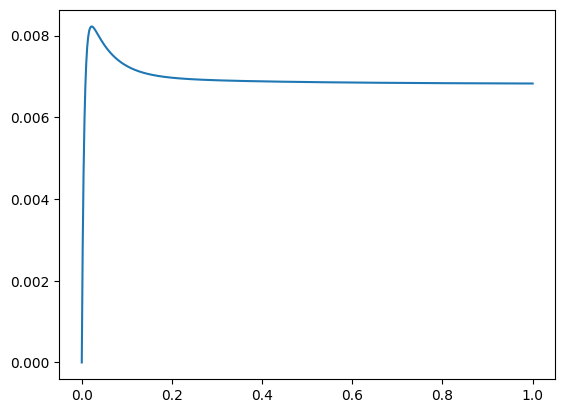

In [25]:
tlist = np.linspace(0,1,1000)
readout_0 = evolve_optical_pumping(rho_relaxed_0, H_0, 1, 1000, cops, PL_op)
plt.plot(tlist,readout_0.expect[0])

## Add in microwave for ground state spin transition

In [26]:
# Temperature-dependent models and ODMR function (with optional strain params)

def D_of_T(T, D0=2870.0, T0=300.0, alpha=-0.074):
  """Linear model for zero-field splitting (MHz) vs temperature (K)."""
  return D0 + alpha * (T - T0)


def T1_of_T(T, T1_0=1e6, T0=300.0, beta=0.01):
  """Phenomenological T1 (microseconds) vs T. Default T1_0=1e6 us (1 s)."""
  return T1_0 * np.exp(-beta * (T - T0))


def T2_of_T(T, T2_0=1e3, T0=300.0, gamma=0.005):
  """Phenomenological T2 (microseconds) vs T. Default T2_0=1e3 us (1 ms)."""
  return max(1.0, T2_0 * np.exp(-gamma * (T - T0)))


def NV_ODMR(BNV, RF_freq, rabi_rate, T=300.0, E_rad_s_param=None, strain_angle_param=None):
  """Temperature-aware NV_ODMR with optional strain coupling.
  If `E_rad_s_param` or `strain_angle_param` are not provided, the function uses
  the global `E_rad_s` and `strain_angle` defined in the constants cell.

  Returns PL readout (scalar) for the given RF frequency and temperature.
  """
  # zero-field splitting at temperature T (MHz)
  D = D_of_T(T)

  # Use provided strain params or fall back to globals
  if E_rad_s_param is None:
    try:
      E_used = E_rad_s
    except NameError:
      E_used = 2 * np.pi * 2.5e6 * 2
  else:
    E_used = E_rad_s_param

  if strain_angle_param is None:
    try:
      angle_used = strain_angle
    except NameError:
      angle_used = np.pi/4
  else:
    angle_used = strain_angle_param

  # convert strain from rad/s to MHz to match D/Delta units used below
  E_MHz = E_used / (2 * np.pi * 1e6)

  # Frequency detunings (MHz)
  Delta_p = (D + 2.8 * BNV) - RF_freq
  Delta_m = (D - 2.8 * BNV) - RF_freq   # B field in Gauss
  Omega_m = rabi_rate
  Omega_p = rabi_rate

  # strain coupling mixes the m=+1 and m=-1 ground states; include as off-diagonal term
  strain_coupling = (np.exp(2j * angle_used) * gs_p1 * gs_m1.dag()
                     + np.exp(-2j * angle_used) * gs_m1 * gs_p1.dag())

  H_rf = 2 * np.pi * (Delta_p * gs_p1 * gs_p1.dag()
                      + Delta_m * gs_m1 * gs_m1.dag()
                      + Omega_p / 2 * gs_0 * gs_p1.dag()
                      + Omega_p / 2 * gs_p1 * gs_0.dag()
                      + Omega_m / 2 * gs_0 * gs_m1.dag()
                      + Omega_m / 2 * gs_m1 * gs_0.dag()
                      + E_MHz * strain_coupling
                      + 4.708E8 * es_p1 * es_p1.dag()
                      + 4.708E8 * es_0 * es_0.dag()
                      + 4.708E8 * es_m1 * es_m1.dag()
                      + 0.5 * 4.708E8 * shelf_state * shelf_state.dag())

  # Dynamic T1/T2 rates (units: 1/us)
  T1_us = T1_of_T(T)
  rate_T1_dyn = 1.0 / T1_us
  T2_us = T2_of_T(T)
  rate_deph = 1.0 / T2_us

  # Reconstruct T1-related collapse operators with temperature-dependent rates
  cop_01_dyn = np.sqrt(rate_T1_dyn) * gs_m1 * gs_0.dag()
  cop_12_dyn = np.sqrt(rate_T1_dyn) * gs_p1 * gs_m1.dag()
  cop_20_dyn = np.sqrt(rate_T1_dyn) * gs_0 * gs_p1.dag()
  cop_10_dyn = cop_01_dyn.dag()
  cop_21_dyn = cop_12_dyn.dag()
  cop_02_dyn = cop_20_dyn.dag()

  # Pure dephasing on ground states (phenomenological)
  cop_phi0 = np.sqrt(rate_deph) * gs_0 * gs_0.dag()
  cop_phim1 = np.sqrt(rate_deph) * gs_m1 * gs_m1.dag()
  cop_phip1 = np.sqrt(rate_deph) * gs_p1 * gs_p1.dag()

  # Build dynamic collapse list: use radiative/ISC/shelve operators already defined globally,
  # but replace the static T1 operators with the dynamic versions and add dephasing.
  dynamic_cops = [cop_03, cop_14, cop_25, cop_30, cop_41, cop_52, cop_36, cop_46, cop_56, cop_60, cop_61, cop_62,
                  cop_01_dyn, cop_12_dyn, cop_20_dyn, cop_10_dyn, cop_21_dyn, cop_02_dyn,
                  cop_phi0, cop_phim1, cop_phip1]

  readout = evolve_optical_pumping(rho_relaxed_0, H_rf, 1, 1000, dynamic_cops, PL_op)
  return readout.expect[0][-1]



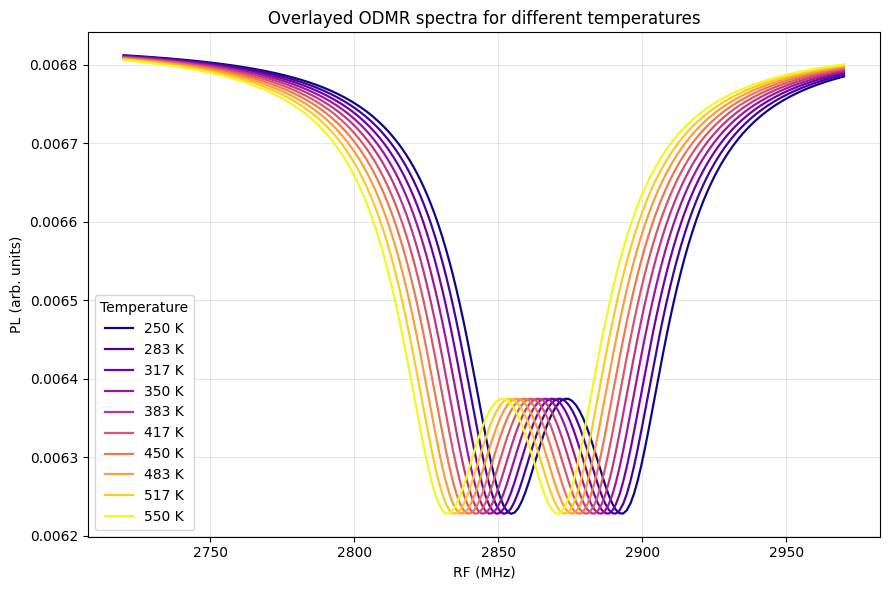

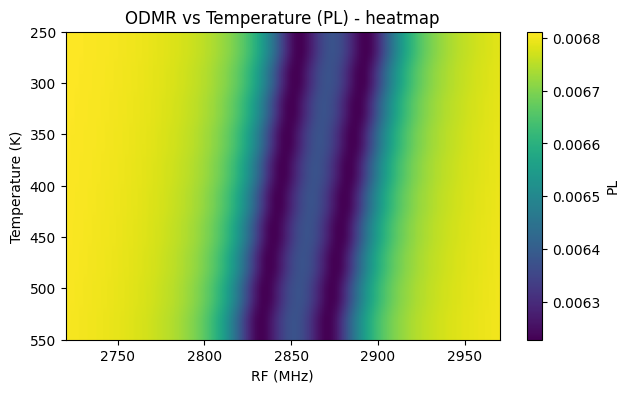

In [27]:

# Temperature sweep for ODMR (compute PL vs RF for each temperature)

temps = np.linspace(250, 550, 10)  # temperatures in K (will produce overlayed curves)
RF_sweep = np.linspace(2720, 2970, 200)  # increase RF resolution slightly for smoother curves
PL_vs_T = np.zeros((len(temps), len(RF_sweep)))
BNV = 0.0  # Gauss (re-use from earlier; can be adjusted)
rabi_rate = 3  # MHz

for ti, T in enumerate(temps):
  for i, RF_freq in enumerate(RF_sweep):
    PL_vs_T[ti, i] = NV_ODMR(BNV, RF_freq, rabi_rate, T)

# Overlay plot: one curve per temperature
plt.figure(figsize=(9,6))
cmap = plt.get_cmap('plasma')
colors = [cmap(i/(len(temps)-1)) for i in range(len(temps))]
for ti, T in enumerate(temps):
  plt.plot(RF_sweep, PL_vs_T[ti], label=f"{T:.0f} K", color=colors[ti], linewidth=1.6)

plt.xlabel('RF (MHz)')
plt.ylabel('PL (arb. units)')
plt.title('Overlayed ODMR spectra for different temperatures')
plt.legend(title='Temperature')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: generate a heatmap of simulated spectra 
plt.figure(figsize=(7,4))
plt.imshow(PL_vs_T, aspect='auto', extent=[RF_sweep[0], RF_sweep[-1], temps[-1], temps[0]])
plt.xlabel('RF (MHz)')
plt.ylabel('Temperature (K)')
plt.title('ODMR vs Temperature (PL) - heatmap')
plt.colorbar(label='PL')
plt.show()


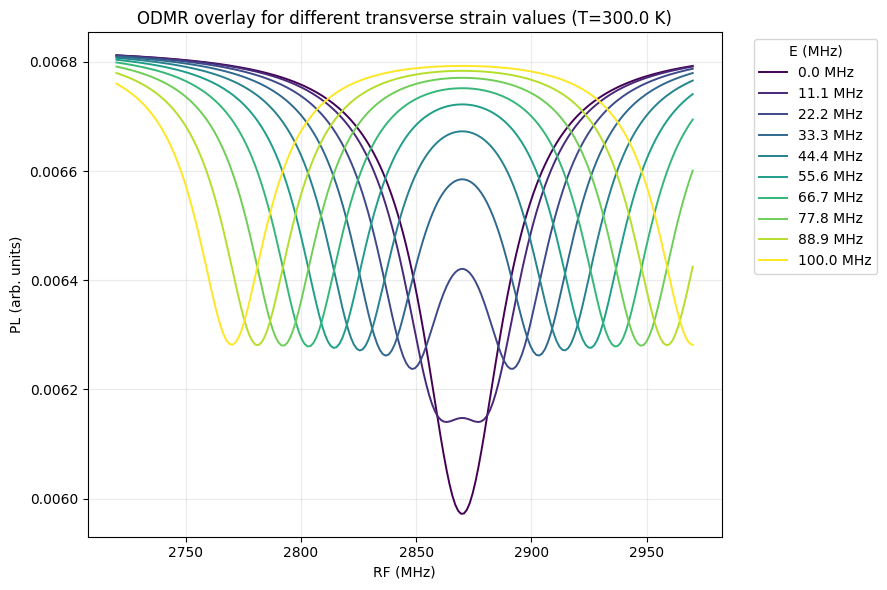

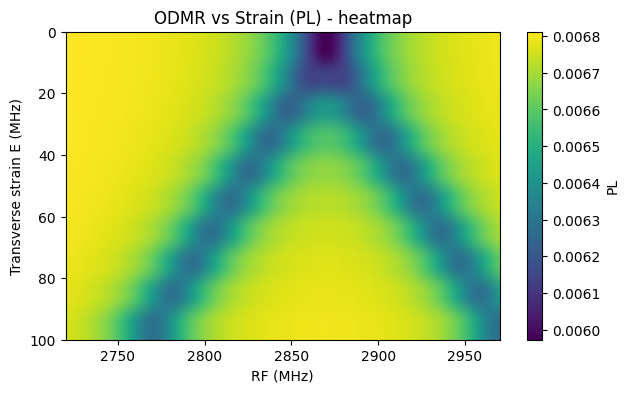

In [28]:
# Strain sweep: vary transverse strain and plot ODMR
# Choose strain values in MHz (transverse splitting), convert inside loop to rad/s
E_MHz_values = np.linspace(0, 100, 10)  # 0..100 MHz in 11 steps
RF_sweep = np.linspace(2720, 2970, 200)
PL_vs_E = np.zeros((len(E_MHz_values), len(RF_sweep)))
BNV = 0.0
rabi_rate = 3
T_fix = 300.0  # run at room temperature for strain sweep

for ei, E_MHz in enumerate(E_MHz_values):
  E_rad_s_val = 2 * np.pi * E_MHz * 1e6
  for i, RF_freq in enumerate(RF_sweep):
    PL_vs_E[ei, i] = NV_ODMR(BNV, RF_freq, rabi_rate, T=T_fix, E_rad_s_param=E_rad_s_val, strain_angle_param=strain_angle)

# Overlay plot for strain sweep
plt.figure(figsize=(9,6))
cmap = plt.get_cmap('viridis')
colors = [cmap(i/(len(E_MHz_values)-1)) for i in range(len(E_MHz_values))]
for ei, E_MHz in enumerate(E_MHz_values):
  plt.plot(RF_sweep, PL_vs_E[ei], label=f"{E_MHz:.1f} MHz", color=colors[ei], linewidth=1.4)

plt.xlabel('RF (MHz)')
plt.ylabel('PL (arb. units)')
plt.title(f'ODMR overlay for different transverse strain values (T={T_fix} K)')
plt.legend(title='E (MHz)', bbox_to_anchor=(1.04,1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Heatmap of PL vs RF (x) and strain (y)
plt.figure(figsize=(7,4))
plt.imshow(PL_vs_E, aspect='auto', extent=[RF_sweep[0], RF_sweep[-1], E_MHz_values[-1], E_MHz_values[0]])
plt.xlabel('RF (MHz)')
plt.ylabel('Transverse strain E (MHz)')
plt.title('ODMR vs Strain (PL) - heatmap')
plt.colorbar(label='PL')
plt.show()


Computed 1/10 temperatures (last T=250.0 K), elapsed 8.1s
Computed 5/10 temperatures (last T=383.3 K), elapsed 40.2s
Computed 5/10 temperatures (last T=383.3 K), elapsed 40.2s
Computed 10/10 temperatures (last T=550.0 K), elapsed 78.7s
Computed 10/10 temperatures (last T=550.0 K), elapsed 78.7s


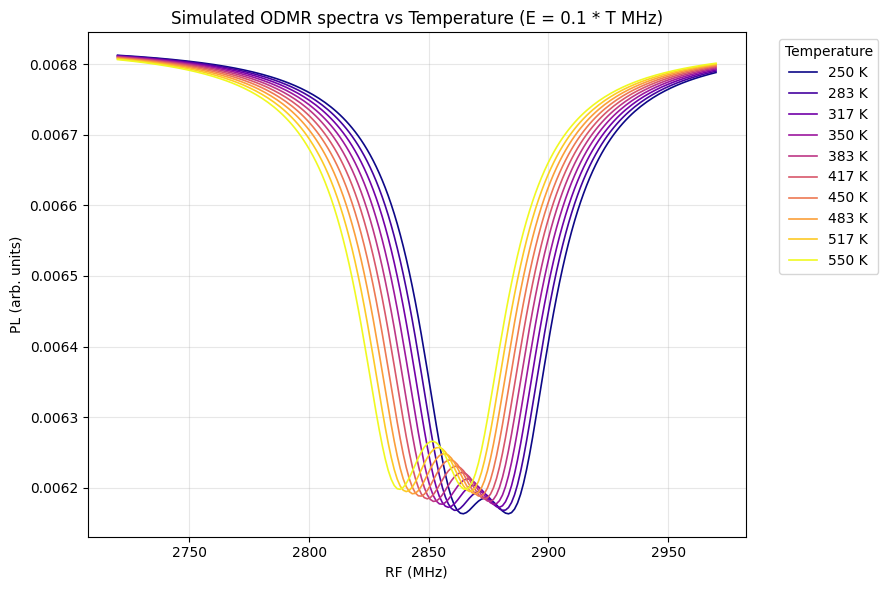

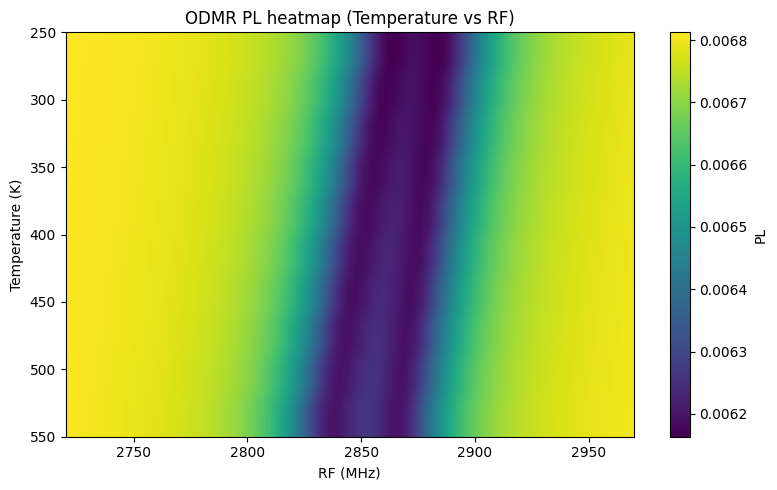

Done: arrays `spec_temps`, `spec_RF`, `spec_PL` available in the notebook


In [29]:
# Simulated ODMR spectra vs Temperature with E increasing linearly: e.g E (MHz) = 0.001 * T

BNV = 0.0
rabi_rate = 3
# temperature vector (use similar range as previous sweeps)
temps_for_spec = np.linspace(250, 550, 10)
# use existing RF_sweep if available, otherwise create one
try:
  RF_grid = RF_sweep
except NameError:
  RF_grid = np.linspace(2720, 2970, 200)
PL_vs_T_and_RF = np.zeros((len(temps_for_spec), len(RF_grid)))
import time
t0 = time.time()
for ti, T in enumerate(temps_for_spec):
  ''' By default do NOT change transverse strain with temperature — keep E constant so both
  m=+1 and m=-1 transitions shift identically with D(T). If you want E to vary with T,
  set `vary_E_with_T = True` below.'''
  vary_E_with_T = True
  if vary_E_with_T:
    E_MHz = 0.01 * T + 10 # linear dependence (MHz) when enabled
  else:
    try:
      E_MHz = E_rad_s / (2 * np.pi * 1e6)
    except NameError:
      E_MHz = 10.0  # fallback constant strain in MHz
  E_rad_s_val = 2 * np.pi * E_MHz * 1e6
  pl_curve = np.zeros(len(RF_grid))
  for ri, rf in enumerate(RF_grid):
    pl_curve[ri] = NV_ODMR(BNV, rf, rabi_rate, T=T, E_rad_s_param=E_rad_s_val, strain_angle_param=strain_angle)
  PL_vs_T_and_RF[ti] = pl_curve
  # progress print every few steps
  if (ti + 1) % 5 == 0 or ti == 0 or ti == len(temps_for_spec)-1:
    dt = time.time() - t0
    print(f'Computed {ti+1}/{len(temps_for_spec)} temperatures (last T={T:.1f} K), elapsed {dt:.1f}s')

# Overlay plot: simulated spectra (one curve per temperature)
plt.figure(figsize=(9,6))
cmap = plt.get_cmap('plasma')
colors = [cmap(i/(len(temps_for_spec)-1)) for i in range(len(temps_for_spec))]
for ti, T in enumerate(temps_for_spec):
  plt.plot(RF_grid, PL_vs_T_and_RF[ti], label=f"{T:.0f} K", color=colors[ti], linewidth=1.2)
plt.xlabel('RF (MHz)')
plt.ylabel('PL (arb. units)')
plt.title('Simulated ODMR spectra vs Temperature (E = 0.1 * T MHz)')
plt.legend(title='Temperature', bbox_to_anchor=(1.04,1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap: temperature (y) vs RF (x). We transpose so rows=temperatures, cols=RF
plt.figure(figsize=(8,5))
plt.imshow(PL_vs_T_and_RF, aspect='auto', extent=[RF_grid[0], RF_grid[-1], temps_for_spec[-1], temps_for_spec[0]])
plt.xlabel('RF (MHz)')
plt.ylabel('Temperature (K)')
plt.title('ODMR PL heatmap (Temperature vs RF)')
plt.colorbar(label='PL')
plt.tight_layout()
plt.show()

# Keep arrays available for later export or analysis
spec_temps = temps_for_spec
spec_RF = RF_grid
spec_PL = PL_vs_T_and_RF
print('Done: arrays `spec_temps`, `spec_RF`, `spec_PL` available in the notebook')